In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
from sklearn.preprocessing import StandardScaler

In [13]:
# Load the encoded network features dataset
df = pd.read_csv('encoded_network_features.csv')
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataset shape: (2827876, 6)
Columns: ['enc1', 'enc2', 'enc3', 'enc4', 'enc5', 'Label']


,enc1,enc2,enc3,enc4,enc5,Label
0,4.490305,1.356725,4.282272,5.004297,0.257939,0
1,4.396287,0.980978,4.062100,4.662739,0.387258,0
2,4.091665,0.762624,3.782046,4.389673,0.334870,0
3,3.642728,0.858193,3.222756,4.029458,0.352682,0
4,4.490354,1.356788,4.282147,5.004299,0.257971,0


In [14]:
# Check label distribution
print("Label distribution:")
print(df['Label'].value_counts())
print("\nLabel percentages:")
print(df['Label'].value_counts(normalize=True) * 100)

Label distribution:
Label
0    2271320
1     556556
Name: count, dtype: int64

Label percentages:
Label
0    80.318939
1    19.681061
Name: proportion, dtype: float64


In [15]:
# Prepare features and labels
X = df.drop('Label', axis=1)
y = df['Label']

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (2827876, 5)
Labels shape: (2827876,)


In [16]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (2262300, 5)
Testing set shape: (565576, 5)


In [17]:
# Scale the features (optional for XGBoost but can help)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Create XGBoost classifier for anomaly detection
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# Train the model
xgb_model.fit(X_train_scaled, y_train)

print("Model training completed.")

Model training completed.


In [19]:
# Make predictions on test set
y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9798506301540376

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    454265
           1       0.94      0.95      0.95    111311

    accuracy                           0.98    565576
   macro avg       0.97      0.97      0.97    565576
weighted avg       0.98      0.98      0.98    565576


Confusion Matrix:
[[448072   6193]
 [  5203 106108]]


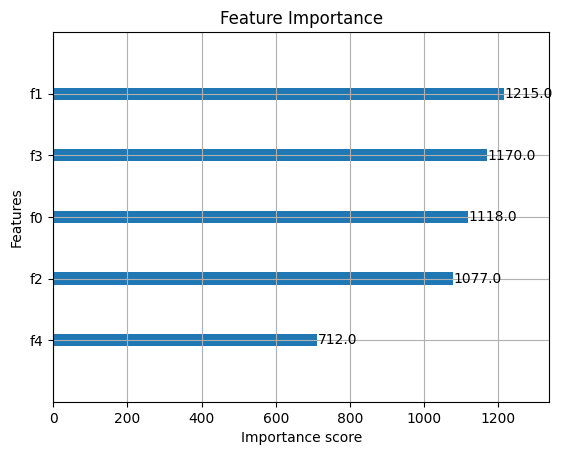


Feature Importance Scores:
f0: 1118.0
f1: 1215.0
f2: 1077.0
f3: 1170.0
f4: 712.0


In [20]:
# Feature importance
import matplotlib.pyplot as plt

xgb.plot_importance(xgb_model)
plt.title('Feature Importance')
plt.show()

# Get feature importance scores
feature_importance = xgb_model.get_booster().get_score(importance_type='weight')
print("\nFeature Importance Scores:")
for feature, score in feature_importance.items():
    print(f"{feature}: {score}")

In [22]:
from pathlib import Path
import joblib

base = Path.cwd()
if (base / "MODELS").exists():
    model_dir = base / "MODELS"
elif (base.parent / "MODELS").exists():
    model_dir = base.parent / "MODELS"
else:
    model_dir = base / "MODELS"

model_dir.mkdir(parents=True, exist_ok=True)
pkl_path = model_dir / "xgboost_model.pkl"
joblib.dump(xgb_model, pkl_path)

print(f"Model saved to: {pkl_path.resolve()}")

Model saved to: C:\Users\dyash\OneDrive\Desktop\GitHub\MINOR_2-NETWORK-ANAMOLY-DETECTION\MODELS\xgboost_model.pkl
